In [1]:
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Create validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (45000, 32, 32, 3)
y_train: (45000, 1)
X_val: (5000, 32, 32, 3)
y_val: (5000, 1)
X_test: (10000, 32, 32, 3)
y_test: (10000, 1)


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([
    Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Flatten(),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

model.summary()

c:\Users\PC-LAB1\Desktop\shok\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [3]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [4]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 124ms/step - accuracy: 0.4202 - loss: 1.6851 - val_accuracy: 0.5542 - val_loss: 1.2397
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6027 - loss: 1.1182 - val_accuracy: 0.5982 - val_loss: 1.1666
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.6752 - loss: 0.9277 - val_accuracy: 0.7006 - val_loss: 0.8303
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 87ms/step - accuracy: 0.7144 - loss: 0.8165 - val_accuracy: 0.7062 - val_loss: 0.8343
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.7428 - loss: 0.7422 - val_accuracy: 0.7532 - val_loss: 0.7012
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.7656 - loss: 0.6800 - val_accuracy: 0.7844 - val_loss: 0.6155
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.7817 - loss: 0.6354 - val_accuracy: 0.7972 - val_loss: 0.5898
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 97ms/step - accuracy: 0.7971 - loss: 0.5985 

In [5]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8534 - loss: 0.4784
Test accuracy: 0.8533999919891357


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


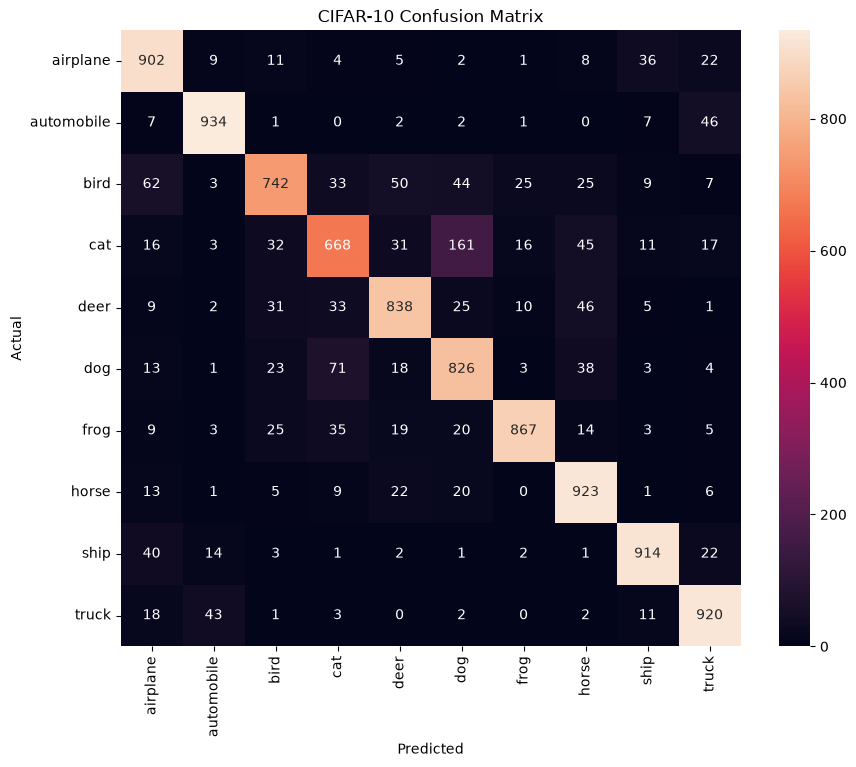

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

predictions = model.predict(X_test)

y_pred = predictions.argmax(axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CIFAR-10 Confusion Matrix")

plt.show()

In [7]:
model.save("cifar10_cnn_85percent.keras")

In [8]:
from tensorflow.keras.models import load_model

model = load_model("cifar10_cnn_85percent.keras")

In [9]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "cifar10_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr, checkpoint]
)

Epoch 1/20
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9069 - loss: 0.2656
Epoch 1: val_accuracy improved from None to 0.84720, saving model to cifar10_best.keras

Epoch 1: finished saving model to cifar10_best.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 90ms/step - accuracy: 0.9068 - loss: 0.2656 - val_accuracy: 0.8472 - val_loss: 0.4875 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9103 - loss: 0.2587
Epoch 2: val_accuracy improved from 0.84720 to 0.85340, saving model to cifar10_best.keras

Epoch 2: finished saving model to cifar10_best.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 114ms/step - accuracy: 0.9103 - loss: 0.2587 - val_accuracy: 0.8534 - val_loss: 0.4863 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9111 - loss: 0.2547
Epoch 3: val_accuracy improved from 0.85340 to 0.87000, saving model to cifar10_best.keras

Epoch 3: finished saving model to cifar10_best.keras
704/704 ━━━━━━━━━━━

In [11]:
from tensorflow.keras.models import load_model

best_model = load_model("cifar10_best.keras")

test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test
)

print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8781 - loss: 0.4546
Test accuracy: 0.8780999779701233


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


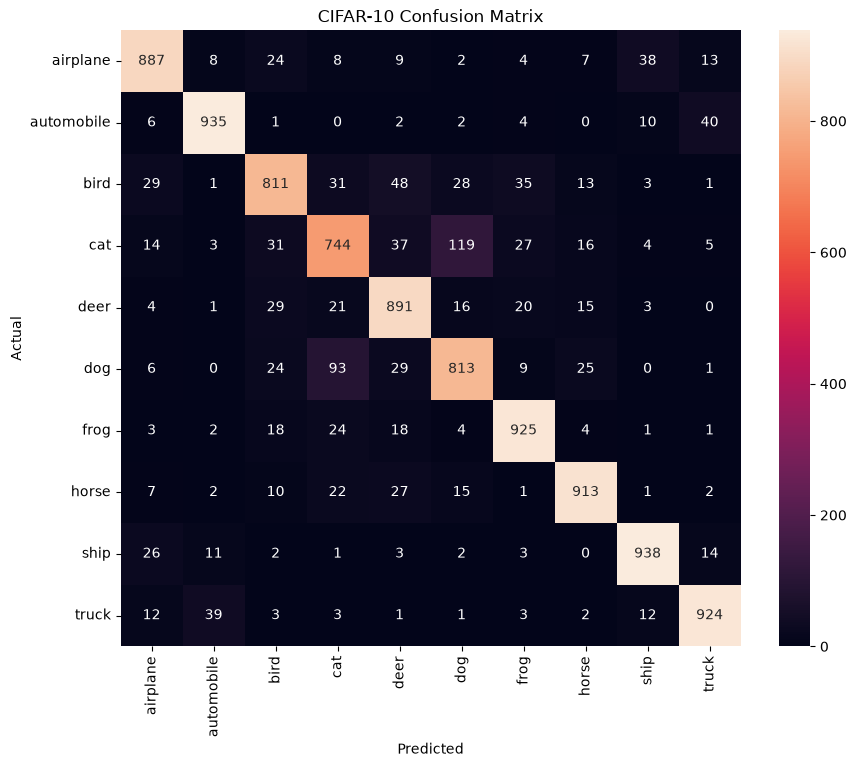

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix

# Load best model
model = load_model("cifar10_best.keras")

# Predict
predictions = model.predict(X_test)

y_pred = predictions.argmax(axis=1)
y_true = y_test.flatten()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CIFAR-10 Confusion Matrix")
plt.show()